In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 1000

age = np.random.randint(18, 80, n)
fever = np.random.randint(0, 2, n)
cough = np.random.randint(0, 2, n)
fatigue = np.random.randint(0, 2, n)
headache = np.random.randint(0, 2, n)
body_pain = np.random.randint(0, 2, n)
breathing_difficulty = np.random.randint(0, 2, n)

blood_pressure = np.random.randint(90, 180, n)
cholesterol = np.random.randint(120, 300, n)

risk_score = (
    0.03 * age
    + 1.5 * fever
    + 1.2 * cough
    + 1.0 * fatigue
    + 0.8 * headache
    + 1.2 * body_pain
    + 2.0 * breathing_difficulty
    + 0.02 * blood_pressure
    + 0.01 * cholesterol
)

threshold = np.median(risk_score)

disease = (risk_score >= threshold).astype(int)

df = pd.DataFrame({
    "Age": age,
    "Fever": fever,
    "Cough": cough,
    "Fatigue": fatigue,
    "Headache": headache,
    "BodyPain": body_pain,
    "BreathingDifficulty": breathing_difficulty,
    "BloodPressure": blood_pressure,
    "Cholesterol": cholesterol,
    "Disease": disease
})


In [2]:
df["Disease"].value_counts()

,count
Disease,
0,500
1,500


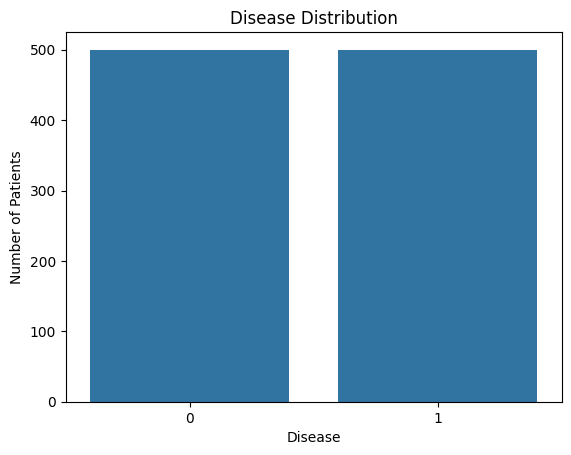

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Disease", data=df)

plt.title("Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Patients")

plt.show()

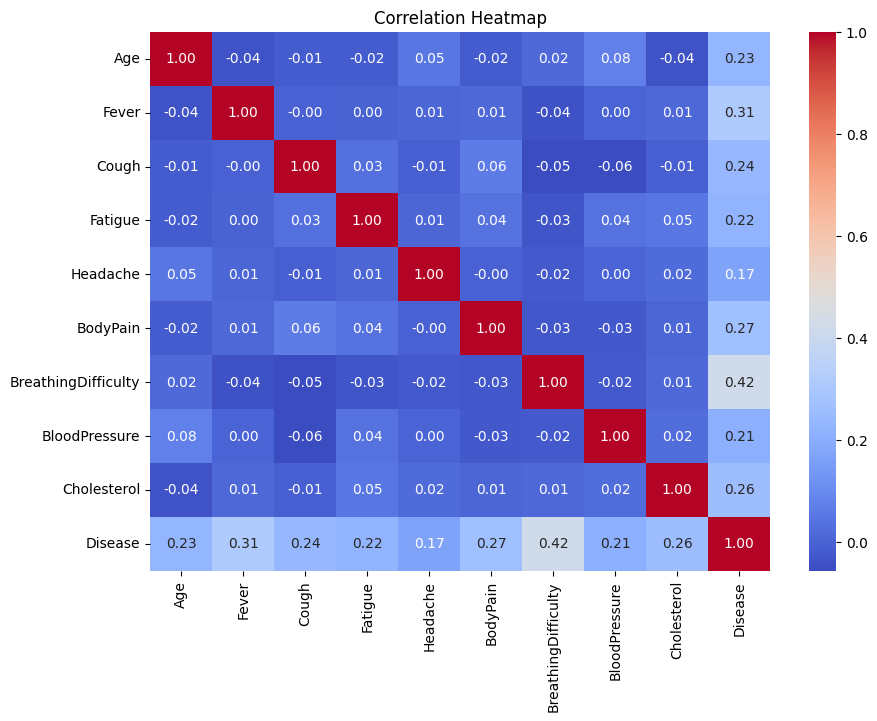

In [4]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Text(0.5, 1.0, 'Age vs Disease')

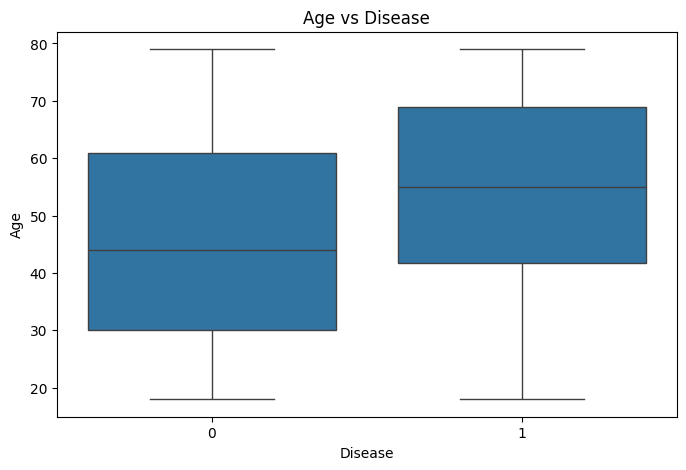

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Disease",
    y="Age",
    data=df
)

plt.title("Age vs Disease")


In [6]:
X = df.drop(
    "Disease",
    axis=1
)

y = df["Disease"]


print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("Disease")



Features:
['Age', 'Fever', 'Cough', 'Fatigue', 'Headache', 'BodyPain', 'BreathingDifficulty', 'BloodPressure', 'Cholesterol']

Target:
Disease


In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import joblib

In [8]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


Training Samples: 800
Testing Samples: 200


In [9]:
model = DecisionTreeClassifier(

    criterion="gini",

    max_depth=5,

    random_state=42

)

In [10]:
model.fit(
    X_train,
    y_train
)

y_pred = model.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    y_pred
)


precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)


print("\n================ MODEL PERFORMANCE ================\n")

print("Accuracy :", round(accuracy, 4))

print("Precision:", round(precision, 4))

print("Recall   :", round(recall, 4))

print("F1 Score :", round(f1, 4))


print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)


================ MODEL PERFORMANCE ================

Accuracy : 0.755
Precision: 0.7429
Recall   : 0.78
F1 Score : 0.761

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.73      0.75       100
           1       0.74      0.78      0.76       100

    accuracy                           0.76       200
   macro avg       0.76      0.76      0.75       200
weighted avg       0.76      0.76      0.75       200



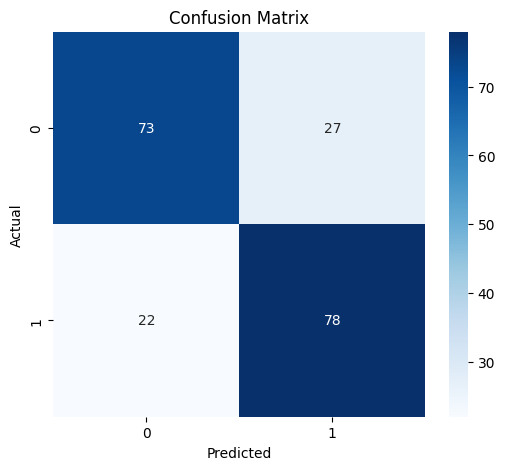

In [11]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


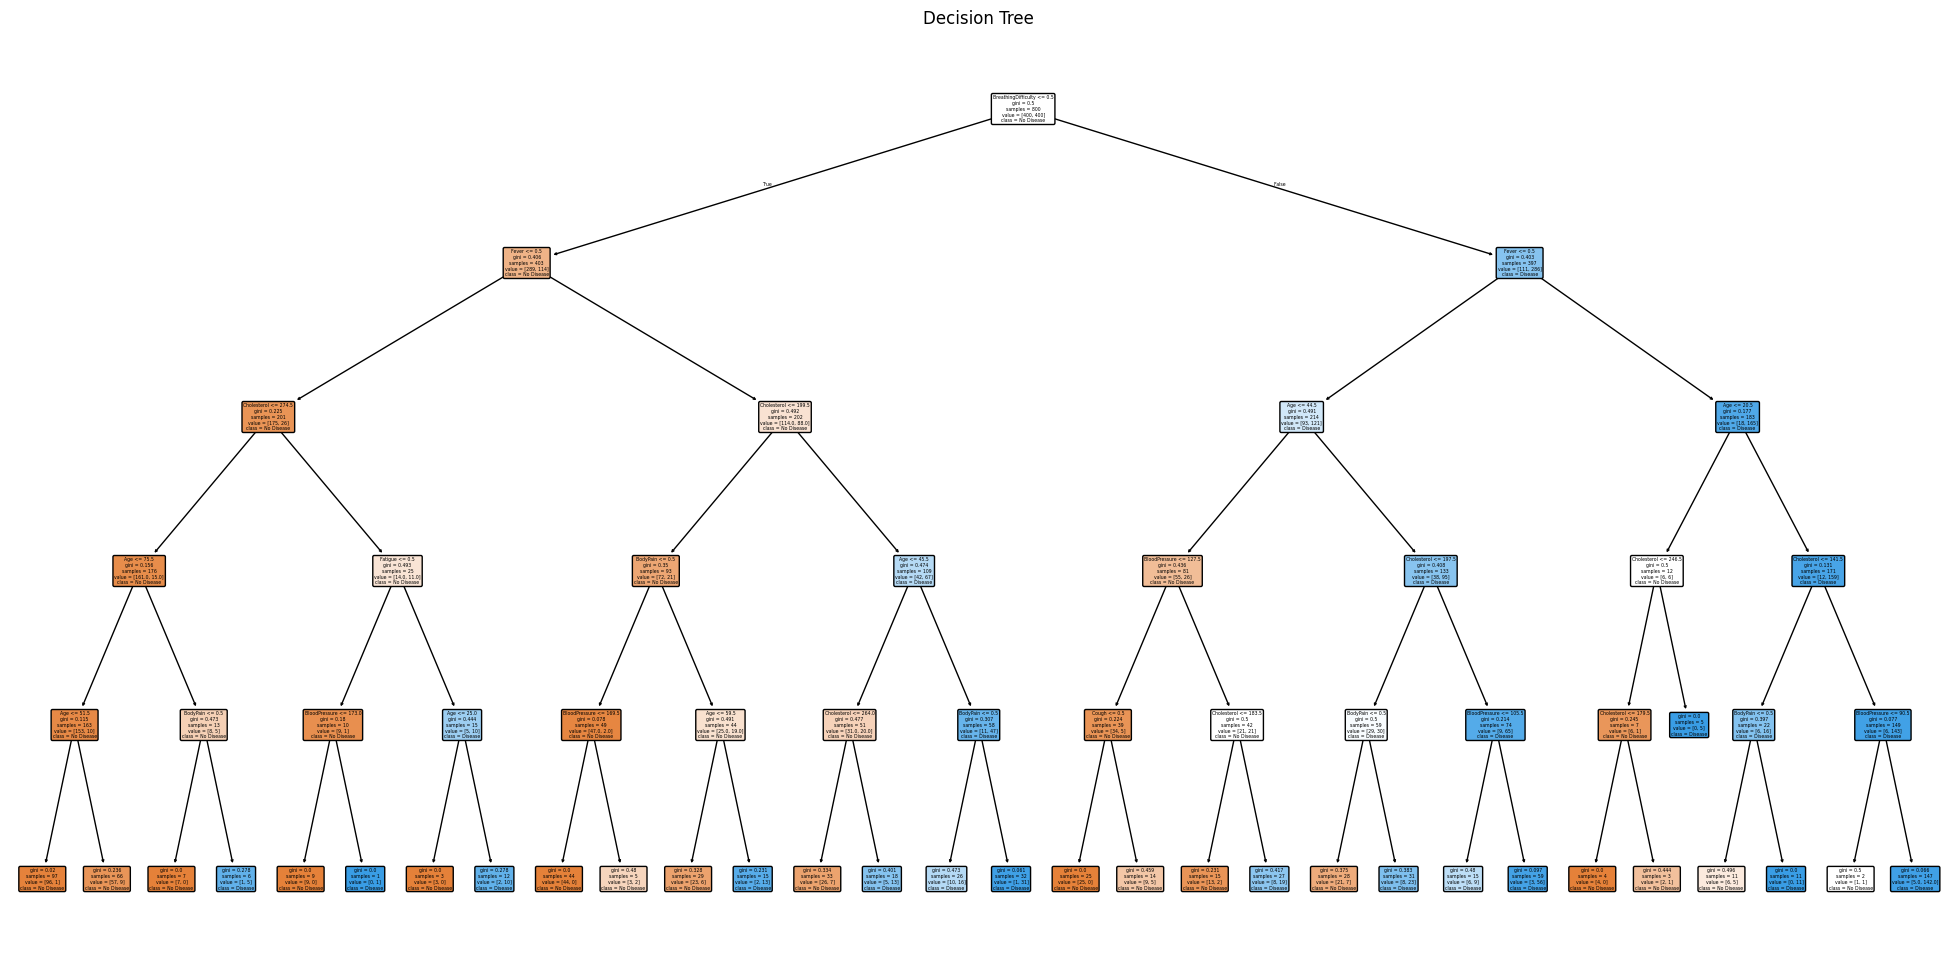

In [12]:
plt.figure(
    figsize=(25, 12)
)

plot_tree(

    model,

    feature_names=X.columns,

    class_names=[
        "No Disease",
        "Disease"
    ],

    filled=True,

    rounded=True

)

plt.title("Decision Tree")

plt.show()


In [13]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})


feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)


print("\n================ FEATURE IMPORTANCE ================\n")

print(feature_importance)




================ FEATURE IMPORTANCE ================

               Feature  Importance
6  BreathingDifficulty    0.299410
8          Cholesterol    0.190615
0                  Age    0.175632
1                Fever    0.161132
5             BodyPain    0.099917
7        BloodPressure    0.049273
3              Fatigue    0.015068
2                Cough    0.008952
4             Headache    0.000000


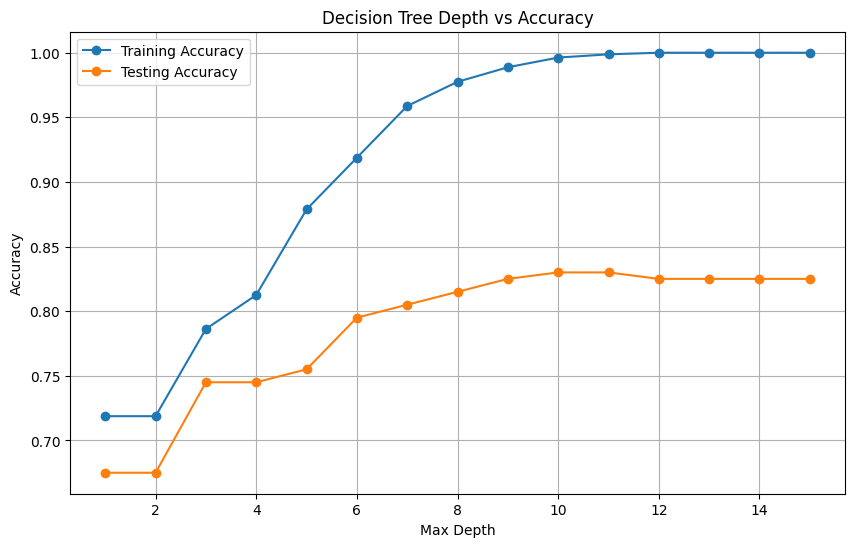

In [14]:
depths = range(1, 16)

train_accuracy = []

test_accuracy = []


for depth in depths:

    temp_model = DecisionTreeClassifier(

        max_depth=depth,

        random_state=42

    )

    temp_model.fit(

        X_train,
        y_train

    )

    train_accuracy.append(

        temp_model.score(
            X_train,
            y_train
        )

    )

    test_accuracy.append(
 temp_model.score(
            X_test,
            y_test
        )

    )


# Plot

plt.figure(figsize=(10, 6))

plt.plot(

    depths,

    train_accuracy,

    marker="o",

    label="Training Accuracy"

)

plt.plot(

    depths,

    test_accuracy,

    marker="o",

    label="Testing Accuracy"
)

plt.xlabel("Max Depth")

plt.ylabel("Accuracy")

plt.title("Decision Tree Depth vs Accuracy")

plt.legend()

plt.grid()

plt.show()

In [15]:
cv_scores = []

depth_range = range(1, 16)


for depth in depth_range:

    temp_model = DecisionTreeClassifier(

        max_depth=depth,

        random_state=42

    )

    scores = cross_val_score(

        temp_model,

        X,

        y,

        cv=5,

        scoring="accuracy"

    )

    cv_scores.append(
        scores.mean()
    )


best_depth = depth_range[
    np.argmax(cv_scores)
]


print("\n================ HYPERPARAMETER TUNING ================\n")

print(
    "Best Max Depth:",
    best_depth
)

print(
    "Best Cross Validation Accuracy:",
    round(
        max(cv_scores),
        4
    )
)


================ HYPERPARAMETER TUNING ================

Best Max Depth: 9
Best Cross Validation Accuracy: 0.827


In [16]:
final_model = DecisionTreeClassifier(

    criterion="gini",

    max_depth=best_depth,

    random_state=42

)

final_model.fit(

    X_train,

    y_train

)


# Final predictions

final_predictions = final_model.predict(
    X_test
)


final_accuracy = accuracy_score(

    y_test,

    final_predictions

)


print(
    "\nFinal Model Accuracy:",
    round(
        final_accuracy,
        4
    )
)


Final Model Accuracy: 0.825


In [17]:
new_patient = pd.DataFrame({

    "Age": [45],

    "Fever": [1],

    "Cough": [1],

    "Fatigue": [1],

    "Headache": [0],

    "BodyPain": [1],

    "BreathingDifficulty": [1],

    "BloodPressure": [145],

    "Cholesterol": [240]

})


prediction = final_model.predict(
    new_patient
)


probability = final_model.predict_proba(
    new_patient
)

print("\n================ NEW PATIENT PREDICTION ================\n")


if prediction[0] == 1:

    print(
        "Prediction: Disease Detected"
    )

else:

    print(
        "Prediction: No Disease Detected"
    )


print(
    "Probability of No Disease:",
    round(
        probability[0][0] * 100,
        2
    ),
    "%"
)

print(
    "Probability of Disease:",
    round(probability[0][1] * 100,
        2
    ),
    "%"
)


================ NEW PATIENT PREDICTION ================

Prediction: Disease Detected
Probability of No Disease: 0.0 %
Probability of Disease: 100.0 %
